# Librerías

In [32]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.datasets import load_iris
import copy

# Definición de la red

In [33]:
# Vamos a añadir una capa lineal oculta con función de activación ReLU
class IrisMLP(nn.Module):
    def __init__(self, hidden_dim: int = 16):
        super().__init__()
        self.fc1 = nn.Linear(4, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, 3)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h = self.relu(self.fc1(x))   # (B, 16)
        logits = self.fc2(h)         # (B, 3)
        return logits

# Dataset y Dataloader

In [34]:
class IrisDataset(Dataset):
    def __init__(self):
        data = load_iris()
        self.X = torch.tensor(
            data.data, dtype=torch.float32
        )  # (150, 4)
        self.y = torch.tensor(
            data.target, dtype=torch.long
        )  # (150,)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [35]:
full_iris_dataset = IrisDataset()
train_dataset, test_dataset, val_dataset = torch.utils.data.random_split(full_iris_dataset, [0.7, 0.2, 0.1], generator=torch.Generator().manual_seed(42))

In [36]:
train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=16, shuffle=False)
val_dataloader = DataLoader(val_dataset, batch_size=16, shuffle=False)

# Ejercicio 1

Haz el entrenamiento de la red durante 100 epochs, reportando el loss de entrenamiento en cada epoch. Finalmente dibuja la gráfica del loss de entrenamiento a lo largo de las epochs.

Epoch 001 | train_loss = 1.5655
Epoch 002 | train_loss = 1.3414
Epoch 003 | train_loss = 1.2034
Epoch 004 | train_loss = 1.1186
Epoch 005 | train_loss = 1.0587
Epoch 006 | train_loss = 0.9994
Epoch 007 | train_loss = 0.9535
Epoch 008 | train_loss = 0.9157
Epoch 009 | train_loss = 0.8814
Epoch 010 | train_loss = 0.8473
Epoch 011 | train_loss = 0.8190
Epoch 012 | train_loss = 0.7892
Epoch 013 | train_loss = 0.7634
Epoch 014 | train_loss = 0.7359
Epoch 015 | train_loss = 0.7142
Epoch 016 | train_loss = 0.6891
Epoch 017 | train_loss = 0.6691
Epoch 018 | train_loss = 0.6517
Epoch 019 | train_loss = 0.6322
Epoch 020 | train_loss = 0.6158
Epoch 021 | train_loss = 0.6032
Epoch 022 | train_loss = 0.5852
Epoch 023 | train_loss = 0.5709
Epoch 024 | train_loss = 0.5584
Epoch 025 | train_loss = 0.5462
Epoch 026 | train_loss = 0.5344
Epoch 027 | train_loss = 0.5243
Epoch 028 | train_loss = 0.5145
Epoch 029 | train_loss = 0.5049
Epoch 030 | train_loss = 0.4969
Epoch 031 | train_loss = 0.4851
Epoch 03

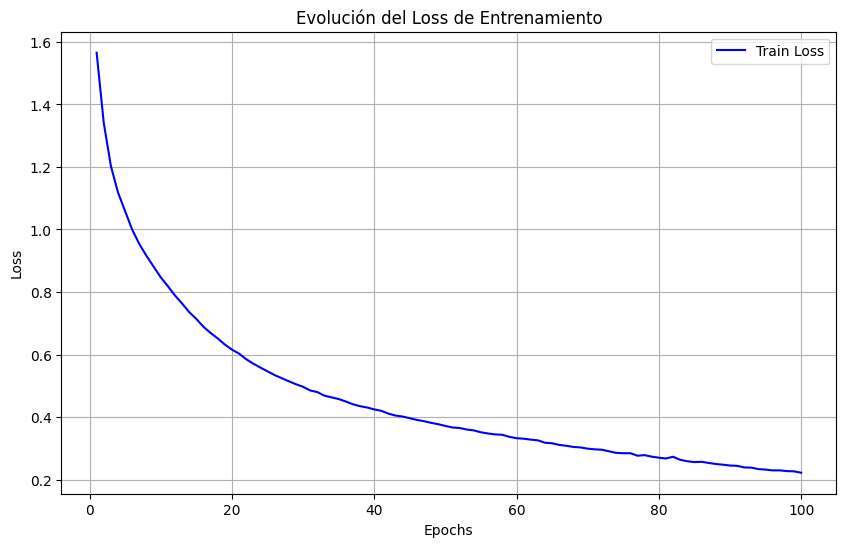

In [37]:
# Modelo, loss y optimizador

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = IrisMLP().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-2)


loss_history = []
num_epochs = 100 # durante un número de epochs

for epoch in range(1, num_epochs + 1):
    # ***   FASE DE ENTRENAMIENTO   ***
    model.train()
    running_loss = 0.0 # para llevar la cuenta del loss
    n_seen = 0
    for xB, yB in train_dataloader :
        xB, yB = xB.to(device), yB.to(device)
        optimizer.zero_grad()      # reset gradientes
        logits = model(xB)         # forward
        loss = criterion(logits, yB)
        loss.backward()            # backward
        optimizer.step()           # update
        running_loss += loss.item() * xB.size(0) # para llevar la cuenta del loss
        n_seen += xB.size(0)           # para llevar la cuenta del loss
    epoch_loss = running_loss / n_seen # loss medio en la epoch
    loss_history.append(epoch_loss)    # Agrego cada epoch a un vector para despues mostrarlo en la gráfica
    print(f"Epoch {epoch:03d} | train_loss = {epoch_loss:.4f}") # reportamos el loss


# ***   FASE Visualización del Loss   ***
import matplotlib.pyplot as plt  # Importamos la librería para graficar

plt.figure(figsize=(10, 6))
plt.plot(list(range(1, num_epochs + 1)), loss_history, label='Train Loss', color='blue')
plt.title('Evolución del Loss de Entrenamiento')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.show() # <--- Mostrar la gráfica

# Ejercicio 2

Antes de finalizar cada epoch, obtén el loss de validación. Haz otra gráfica que muestre ambos losses. Interpreta la gráfica.

Epoch 010 | Train Loss: 0.0574 | Val Loss: 0.7855
Epoch 020 | Train Loss: 0.0574 | Val Loss: 0.6394
Epoch 030 | Train Loss: 0.0574 | Val Loss: 0.5130
Epoch 040 | Train Loss: 0.0574 | Val Loss: 0.4706
Epoch 050 | Train Loss: 0.0574 | Val Loss: 0.4272
Epoch 060 | Train Loss: 0.0574 | Val Loss: 0.3894
Epoch 070 | Train Loss: 0.0574 | Val Loss: 0.3697
Epoch 080 | Train Loss: 0.0574 | Val Loss: 0.3377
Epoch 090 | Train Loss: 0.0574 | Val Loss: 0.3208
Epoch 100 | Train Loss: 0.0574 | Val Loss: 0.3056


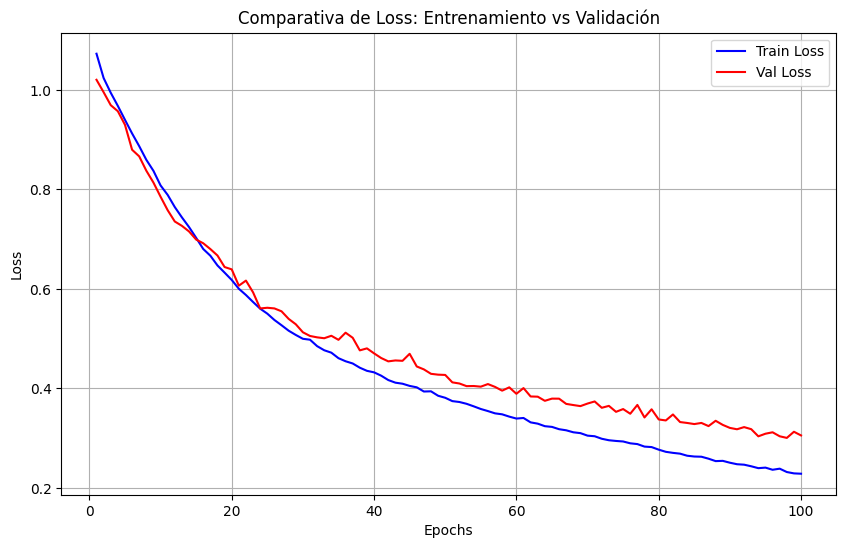

In [21]:
# Modelo, loss y optimizador

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = IrisMLP().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-2)


loss_history = []
val_loss_history = [] # <--- Nueva lista para el loss de validación
num_epochs = 100 # durante un número de epochs

for epoch in range(1, num_epochs + 1):
    # ***   FASE DE ENTRENAMIENTO   ***
    model.train()
    running_loss = 0.0    # para llevar la cuenta del loss
    n_seen = 0
    for xB, yB in train_dataloader :
        xB, yB = xB.to(device), yB.to(device)
        optimizer.zero_grad()      # reset gradientes
        logits = model(xB)         # forward
        loss = criterion(logits, yB)
        loss.backward()            # backward cALCULA TODOS LOS GRADIENTES
        optimizer.step()           # update
        running_loss += loss.item() * xB.size(0) # para llevar la cuenta del loss
        n_seen += xB.size(0)           # para llevar la cuenta del loss
    epoch_loss = running_loss / n_seen # loss medio en la epoch
    loss_history.append(epoch_loss)    # Agrego cada epoch a un vector para despues mostrarlo en la gráfica
    #print(f"Epoch {epoch:03d} | train_loss = {epoch_loss:.4f}") # reportamos el loss

    # ***   FASE DE EVALUACIÓN   ***
    model.eval()
    correct = 0
    total = 0
    test_loss = 0.0
    
    with torch.no_grad():
        for xT, yT in test_dataloader:
            xT, yT = xT.to(device), yT.to(device)
            logits_test = model(xT)
            loss_t = criterion(logits_test, yT)
            test_loss += loss_t.item() * xT.size(0)
            
            preds = logits_test.argmax(dim=1)
            correct += (preds == yT).sum().item()
            total += yT.size(0)
    
    avg_test_loss = test_loss / total
    accuracy = correct / total
    
    print(f"\n--- Resultados en Test ---")
    print(f"  Loss:     {avg_test_loss:.4f}")
    print(f"  Accuracy: {accuracy * 100:.2f}%")
    

    # ***   FASE DE VALIDACIÓN   ***

    # =========================
    # 3. FASE DE VALIDACIÓN
    # =========================
    model.eval() # Ponemos el modelo en modo evaluación
    running_val_loss = 0.0
    n_val_seen = 0
    
    with torch.no_grad(): # Desactivamos el cálculo de gradientes
        for xV, yV in test_dataloader: # Usamos el dataloader de validación
            xV, yV = xV.to(device), yV.to(device)
            logits_val = model(xV)
            loss_v = criterion(logits_val, yV)
            running_val_loss += loss_v.item() * xV.size(0)
            n_val_seen += xV.size(0)
            
    epoch_val_loss = running_val_loss / n_val_seen # val_dataloader
    val_loss_history.append(epoch_val_loss)

    if epoch % 10 == 0: # Imprimimos cada 10 epochs para no llenar la pantalla
        print(f"Epoch {epoch:03d} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")

# --- GRAFICAR AMBOS ---
plt.figure(figsize=(10, 6))
plt.plot(range(1, num_epochs + 1), loss_history, label='Train Loss', color='blue')
plt.plot(range(1, num_epochs + 1), val_loss_history, label='Val Loss', color='red')
plt.title('Comparativa de Loss: Entrenamiento vs Validación')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Ejercicio 3

Escoge una de estas dos opciones:
- Implementa early stopping con X epochs de paciencia.
- Implementa un mecanismo de guardar el mejor modelo y monitorización del loss de validación durante el entrenamiento.

**Nota.** Para guardar y restaurar el estado de la red:
```python
best_state = copy.deepcopy(model.state_dict())
model.load_state_dict(best_state)
```

In [24]:
import copy # <--- IMPORTANTE: Necesario para copiar el estado del modelo

# ... (Tu código de definición de modelo, criterio y optimizador) 
    # Ya esta en celdas anteriores train_dataloader / test_dataloader / val_dataloader 

num_epochs = 100
loss_history = []
val_loss_history = []

# --- INICIALIZACIÓN PARA EL MEJOR MODELO ---
best_val_loss = float('inf') # Empezamos con un error "infinito"
best_model_state = None      # Aquí guardaremos los mejores pesos

# --- FASE DE ENTRENAMIENTO (igual que antes) ---
for epoch in range(1, num_epochs + 1):   
    model.train()
    running_loss = 0.0
    n_seen = 0
    for xB, yB in train_dataloader:
        xB, yB = xB.to(device), yB.to(device)
        optimizer.zero_grad()
        logits = model(xB)
        loss = criterion(logits, yB)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * xB.size(0)
        n_seen += xB.size(0)
    
    epoch_train_loss = running_loss / n_seen
    loss_history.append(epoch_train_loss)

# --- FASE DE VALIDACIÓN ---
    model.eval()
    running_val_loss = 0.0
    n_val_seen = 0
    with torch.no_grad():
        for xV, yV in test_dataloader:
            xV, yV = xV.to(device), yV.to(device)
            logits_val = model(xV)
            loss_v = criterion(logits_val, yV)
            running_val_loss += loss_v.item() * xV.size(0)
            n_val_seen += xV.size(0)
            
    epoch_val_loss = running_val_loss / n_val_seen
    val_loss_history.append(epoch_val_loss)

# --- LÓGICA DE GUARDADO DEL MEJOR MODELO ---
    if epoch_val_loss < best_val_loss:
        # Si el error actual es menor que el mejor que conocíamos:
        best_val_loss = epoch_val_loss
        # Guardamos una "foto" de los pesos actuales
        best_model_state = copy.deepcopy(model.state_dict())
        print(f"Epoch {epoch:03d}: ¡Nuevo mejor modelo guardado! (Val Loss: {best_val_loss:.4f})")

# --- AL FINALIZAR EL ENTRENAMIENTO ---
# Restauramos los mejores pesos en el modelo
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print("\nEntrenamiento finalizado. Se ha restaurado el modelo con el menor loss de validación.")

Epoch 001: ¡Nuevo mejor modelo guardado! (Val Loss: 0.1872)
Epoch 002: ¡Nuevo mejor modelo guardado! (Val Loss: 0.1850)
Epoch 004: ¡Nuevo mejor modelo guardado! (Val Loss: 0.1848)
Epoch 007: ¡Nuevo mejor modelo guardado! (Val Loss: 0.1848)
Epoch 017: ¡Nuevo mejor modelo guardado! (Val Loss: 0.1841)
Epoch 019: ¡Nuevo mejor modelo guardado! (Val Loss: 0.1835)
Epoch 021: ¡Nuevo mejor modelo guardado! (Val Loss: 0.1829)
Epoch 023: ¡Nuevo mejor modelo guardado! (Val Loss: 0.1827)
Epoch 028: ¡Nuevo mejor modelo guardado! (Val Loss: 0.1822)
Epoch 032: ¡Nuevo mejor modelo guardado! (Val Loss: 0.1819)
Epoch 035: ¡Nuevo mejor modelo guardado! (Val Loss: 0.1816)
Epoch 037: ¡Nuevo mejor modelo guardado! (Val Loss: 0.1814)
Epoch 044: ¡Nuevo mejor modelo guardado! (Val Loss: 0.1808)
Epoch 052: ¡Nuevo mejor modelo guardado! (Val Loss: 0.1805)
Epoch 055: ¡Nuevo mejor modelo guardado! (Val Loss: 0.1800)
Epoch 057: ¡Nuevo mejor modelo guardado! (Val Loss: 0.1799)
Epoch 062: ¡Nuevo mejor modelo guardado!

# Ejercicio 4

Evalúa la mejor red obtenida en el apartado anterior. Usa `accuracy` como métrica.

In [29]:
def evaluate_accuracy(loader, model, device):
    # 1. Ponemos el modelo en modo evaluación (desactiva Dropout, BatchNorm, etc.)
    model.eval()
    
    correct = 0
    total = 0
    
    # 2. Desactivamos el cálculo de gradientes para ir más rápido y usar menos memoria
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            
            # 3. Forward: obtenemos las puntuaciones (logits)
            outputs = model(x)
            
            # 4. La clase predicha es la que tenga el valor más alto (el índice)
            # torch.max devuelve (valor_máximo, índice_del_máximo)
            _, predicted = torch.max(outputs.data, 1)
            
            # 5. Contamos cuántos elementos hay en total y cuántos coinciden
            total += y.size(0)
            correct += (predicted == y).sum().item()
            
    # Calculamos el porcentaje final
    accuracy = 100 * correct / total
    return accuracy

# Ejecución
accuracy = evaluate_accuracy(test_dataloader, model, device)
print(f"Accuracy en el conjunto de test: {accuracy:.2f}%")

Accuracy en el conjunto de test: 93.33%


# Ejercicio 5

Aumenta la hidden dimension a 1024 e implementa algún método de regularización visto en clase ($L_1,L_2$ o dropout).
- [`nn.Dropout`](https://pytorch.org/docs/stable/generated/torch.nn.Dropout.html)
- [`weight_decay`](https://docs.pytorch.org/docs/stable/generated/torch.optim.SGD.html)
- Para $L_1$ hay que hacerla a mano, añadiendo la norma $L_1$ de los parámetros al loss.


In [31]:
import torch.nn as nn

class IrisMLP(nn.Module):
    def __init__(self):
        super(IrisMLP, self).__init__()
        # Capa de entrada (4 características) -> Capa oculta (1024 neuronas)
        self.fc1 = nn.Linear(4, 1024)
        # Dropout: apaga el 50% de las neuronas aleatoriamente en cada paso
        self.dropout = nn.Dropout(p=0.5) 
        # Capa de salida (3 clases de flores)
        self.fc2 = nn.Linear(1024, 3)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x) # El dropout se aplica después de la activación
        x = self.fc2(x)
        return x

model = IrisMLP().to(device)